In [ ]:
#same metrics as aggregated but for regions
#edited: 6/25

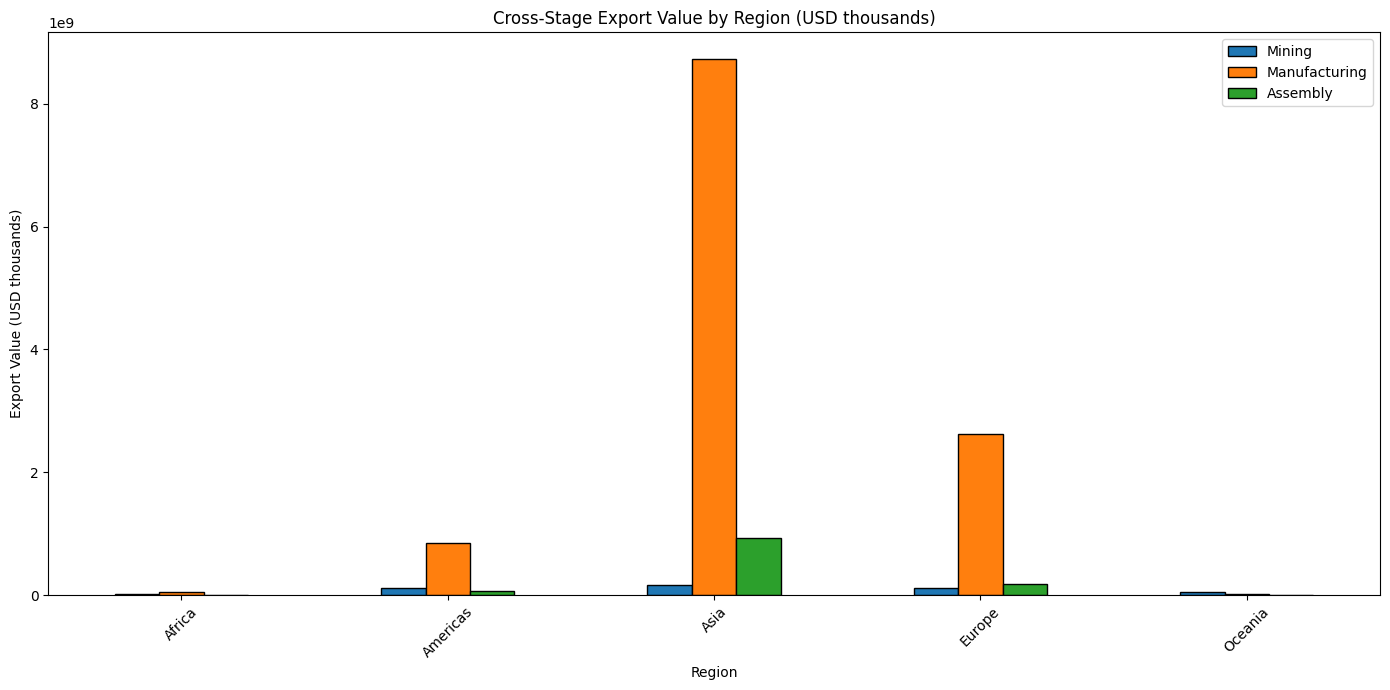

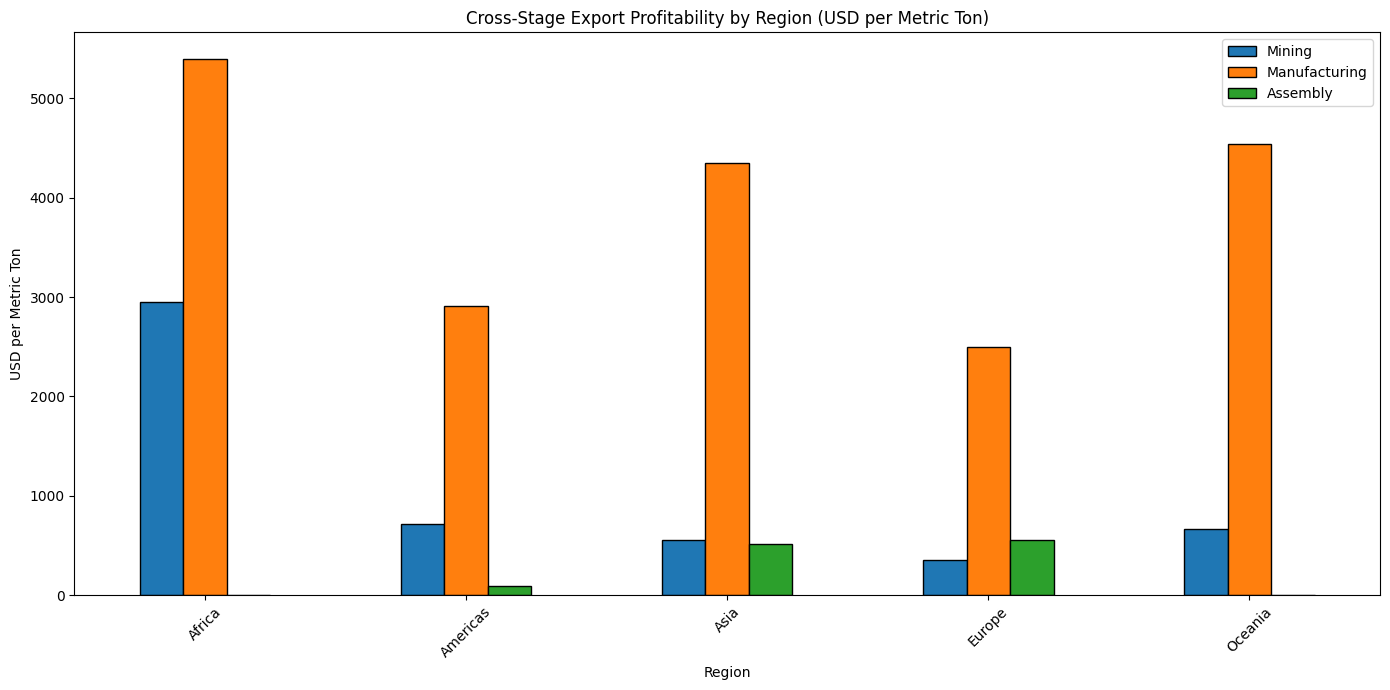

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

#  Load Precomputed Data 
region_val = pd.read_csv("../data/regional aggregated data/region_export_value.csv", index_col=0)
region_profit = pd.read_csv("../data/regional aggregated data/region_export_profitability.csv", index_col=0)

#  Plot Cross-Stage Export Value by Region 
ax1 = region_val.plot(kind="bar", figsize=(14, 7), edgecolor="black")
ax1.set_title("Cross-Stage Export Value by Region (USD thousands)")
ax1.set_ylabel("Export Value (USD thousands)")
ax1.set_xlabel("Region")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#  Plot Cross-Stage Profitability by Region 
ax2 = region_profit.plot(kind="bar", figsize=(14, 7), edgecolor="black")
ax2.set_title("Cross-Stage Export Profitability by Region (USD per Metric Ton)")
ax2.set_ylabel("USD per Metric Ton")
ax2.set_xlabel("Region")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

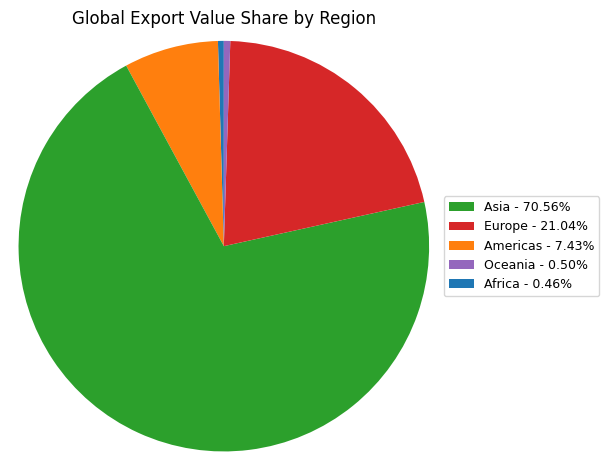

In [8]:
import matplotlib.pyplot as plt
import numpy as np

#  Assuming region_val is already defined 
# Each row is a region, columns are ["Mining", "Manufacturing", "Assembly"]
region_total_value = region_val.sum(axis=1)
total_global_value = region_total_value.sum()
region_value_share = region_total_value / total_global_value * 100

#  Prepare labels and pie data 
regions = region_value_share.index.to_numpy()
percentages = region_value_share.to_numpy()

#  Pie chart 
patches, texts = plt.pie(percentages, startangle=90, radius=1.2)

# Create formatted legend labels
labels = [f"{r} - {p:.2f}%" for r, p in zip(regions, percentages)]

# Sort patches and labels by value (descending)
patches, labels, _ = zip(*sorted(zip(patches, labels, percentages),
                                 key=lambda x: x[2], reverse=True))

#  Plot legend separately on the right 
plt.legend(patches, labels, loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9)
plt.title("Global Export Value Share by Region")
plt.tight_layout()
plt.savefig("region_export_value_share.png", bbox_inches='tight')
plt.show()
